# Clustering de Series de Tiempo

# 1. Introducción
##1.1 ¿Qué es clustering?
Clustering es un tipo de aprendizaje no supervisado cuya idea central es encontrar similitudes entre distintos puntos de datos y agruparlos de forma que los elementos dentro de un mismo grupo (*cluster*) se parezcan más entre sí que a los de otros grupos. Es una de las tareas principales del análisis exploratorio de datos y se utiliza en campos como bioinformática, reconocimiento de patrones, análisis de imágenes, machine learning, etc.## 1.2 ¿Qué son las series de tiempo?Las series de tiempo son secuencias de datos generadas al medir una variable (ventas, temperatura, precios de acciones, etc.) a intervalos regulares. Están indexadas en orden temporal y se utilizan comúnmente en pronóstico meteorológico, econometría, predicción de sismos, procesamiento de señales, entre otros.![Time series example](https://upload.wikimedia.org/wikipedia/commons/7/77/Random-data-plus-trend-r2.png)## 1.3 Enfoques de clustering para series de tiempoEn este notebook exploraremos **cuatro enfoques** distintos:1. **Feature-based (K-Means):** extraer estadísticas descriptivas de cada serie (tendencia, autocorrelaciones, espectro, SAX) y clusterizar en ese espacio de características.2. **Shape-based con DTW + Jerárquico:** usar Dynamic Time Warping como medida de distancia elástica y agrupar con linkage jerárquico.3. **Shape-based con DTW + Espectral:** convertir la matriz DTW en una matriz de afinidad y aplicar clustering espectral.4. **Model-based (AR):** ajustar un modelo autorregresivo AR(p) a cada serie y clusterizar en el espacio de parámetros.# 2. Datos y exploración## 2.1 Carga de datos

In [ ]:
# Dependencias (solo se necesitan scipy, sklearn, matplotlib, pandas, numpy, openpyxl)
# !pip install openpyxl  # descomentar si es necesario

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from IPython.display import Image, display

import warnings
warnings.filterwarnings('ignore')

In [2]:
#
precios_5y = pd.read_excel('precios_5y.xlsx')
precios_5y.head()

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,AC.MX,2020-12-01,80.088813,82.370130,79.983648,81.998001,NaN,1060283
1,AC.MX,2020-12-02,81.965638,86.487828,81.407441,84.780884,NaN,1864111
2,AC.MX,2020-12-03,84.497719,84.829402,82.628982,84.344017,NaN,1233829
3,AC.MX,2020-12-04,84.554379,87.126929,82.968783,83.251930,NaN,1451388
4,AC.MX,2020-12-07,83.648301,85.525129,83.106288,84.424919,NaN,1093850


## 2.2 PreprocesamientoTrabajamos con datos de precios de cierre de acciones a lo largo de 5 años. Para que el análisis sea consistente, filtramos únicamente los tickers que tienen exactamente **1,260 observaciones** (≈ 5 años × 252 días hábiles), es decir, series completas sin datos faltantes.

In [3]:
#
ticker_counts_df = precios_5y['Ticker'].value_counts().reset_index()
ticker_counts_df.columns = ['Ticker', 'Count']

# 1260 ≈ 5 años × 252 días de trading
expected_obs = ticker_counts_df['Count'].max()
print(f"Número máximo de observaciones por ticker: {expected_obs}")

tickers_1260 = ticker_counts_df[ticker_counts_df['Count'] == expected_obs].reset_index(drop=True)
print(f"Tickers con serie completa: {tickers_1260.shape[0]}")

Número máximo de observaciones por ticker: 1260
Tickers con serie completa: 55


In [4]:
#
tickers_sel = tickers_1260.Ticker.to_list()

precios_wide = precios_5y.pivot_table(index='Date', columns='Ticker', values='Close')
precios_filtered_by_tickers = precios_wide[tickers_sel]

print(f"Matriz de precios: {precios_filtered_by_tickers.shape[0]} fechas × {precios_filtered_by_tickers.shape[1]} tickers")
precios_filtered_by_tickers.head()

Matriz de precios: 1260 fechas × 55 tickers


Ticker,AC.MX,ALFAA.MX,AGUA.MX,ASURB.MX,ARA.MX,ALSEA.MX,ALPEKA.MX,VOLARA.MX,PINFRA.MX,POCHTECB.MX,...,TLEVISACPO.MX,SORIANAB.MX,LABB.MX,LIVEPOLC-1.MX,MEGACPO.MX,MFRISCOA-1.MX,OMAB.MX,NEMAKA.MX,ORBIA.MX,PE&OLES.MX
Date,,,,,,,,,,,,,,,,,,,,,
2020-12-01,81.998001,14.423355,19.003740,234.382065,2.340446,26.986250,17.688763,22.100000,135.001297,5.90,...,29.609810,16.208391,15.298789,59.300961,55.970215,2.009705,95.664413,6.755221,39.438290,315.342743
2020-12-02,84.780884,14.649711,19.646788,234.881897,2.456228,27.015467,17.678942,22.360001,140.923370,6.03,...,29.208834,16.985706,15.523301,61.014755,57.431705,2.004693,96.228760,6.725243,39.632896,335.983124
2020-12-03,84.344017,15.220123,19.722937,233.041565,2.572010,27.697186,17.453045,22.430000,140.915054,6.00,...,30.180084,16.736198,15.819971,63.218220,55.924557,1.994670,94.854065,6.905115,40.476135,350.286469
2020-12-04,83.251930,15.229179,18.936052,229.179123,2.878004,27.862747,17.364651,22.209999,145.672653,6.13,...,29.992964,17.216021,15.667629,65.054436,56.320370,1.964600,92.177017,6.895123,39.660686,334.253937
2020-12-07,84.424919,15.383101,18.487612,228.315735,2.886275,27.843267,17.482512,23.459999,143.601593,5.92,...,29.547434,17.273598,15.819971,65.386703,56.274693,1.944553,89.456558,6.755221,39.280762,339.111664


## 2.3 Exploración visualVisualizamos una muestra aleatoria de 9 series, tanto en precios absolutos como normalizados al día 1 (retorno acumulado). La normalización permite comparar la *forma* de las series independientemente de su escala de precios.

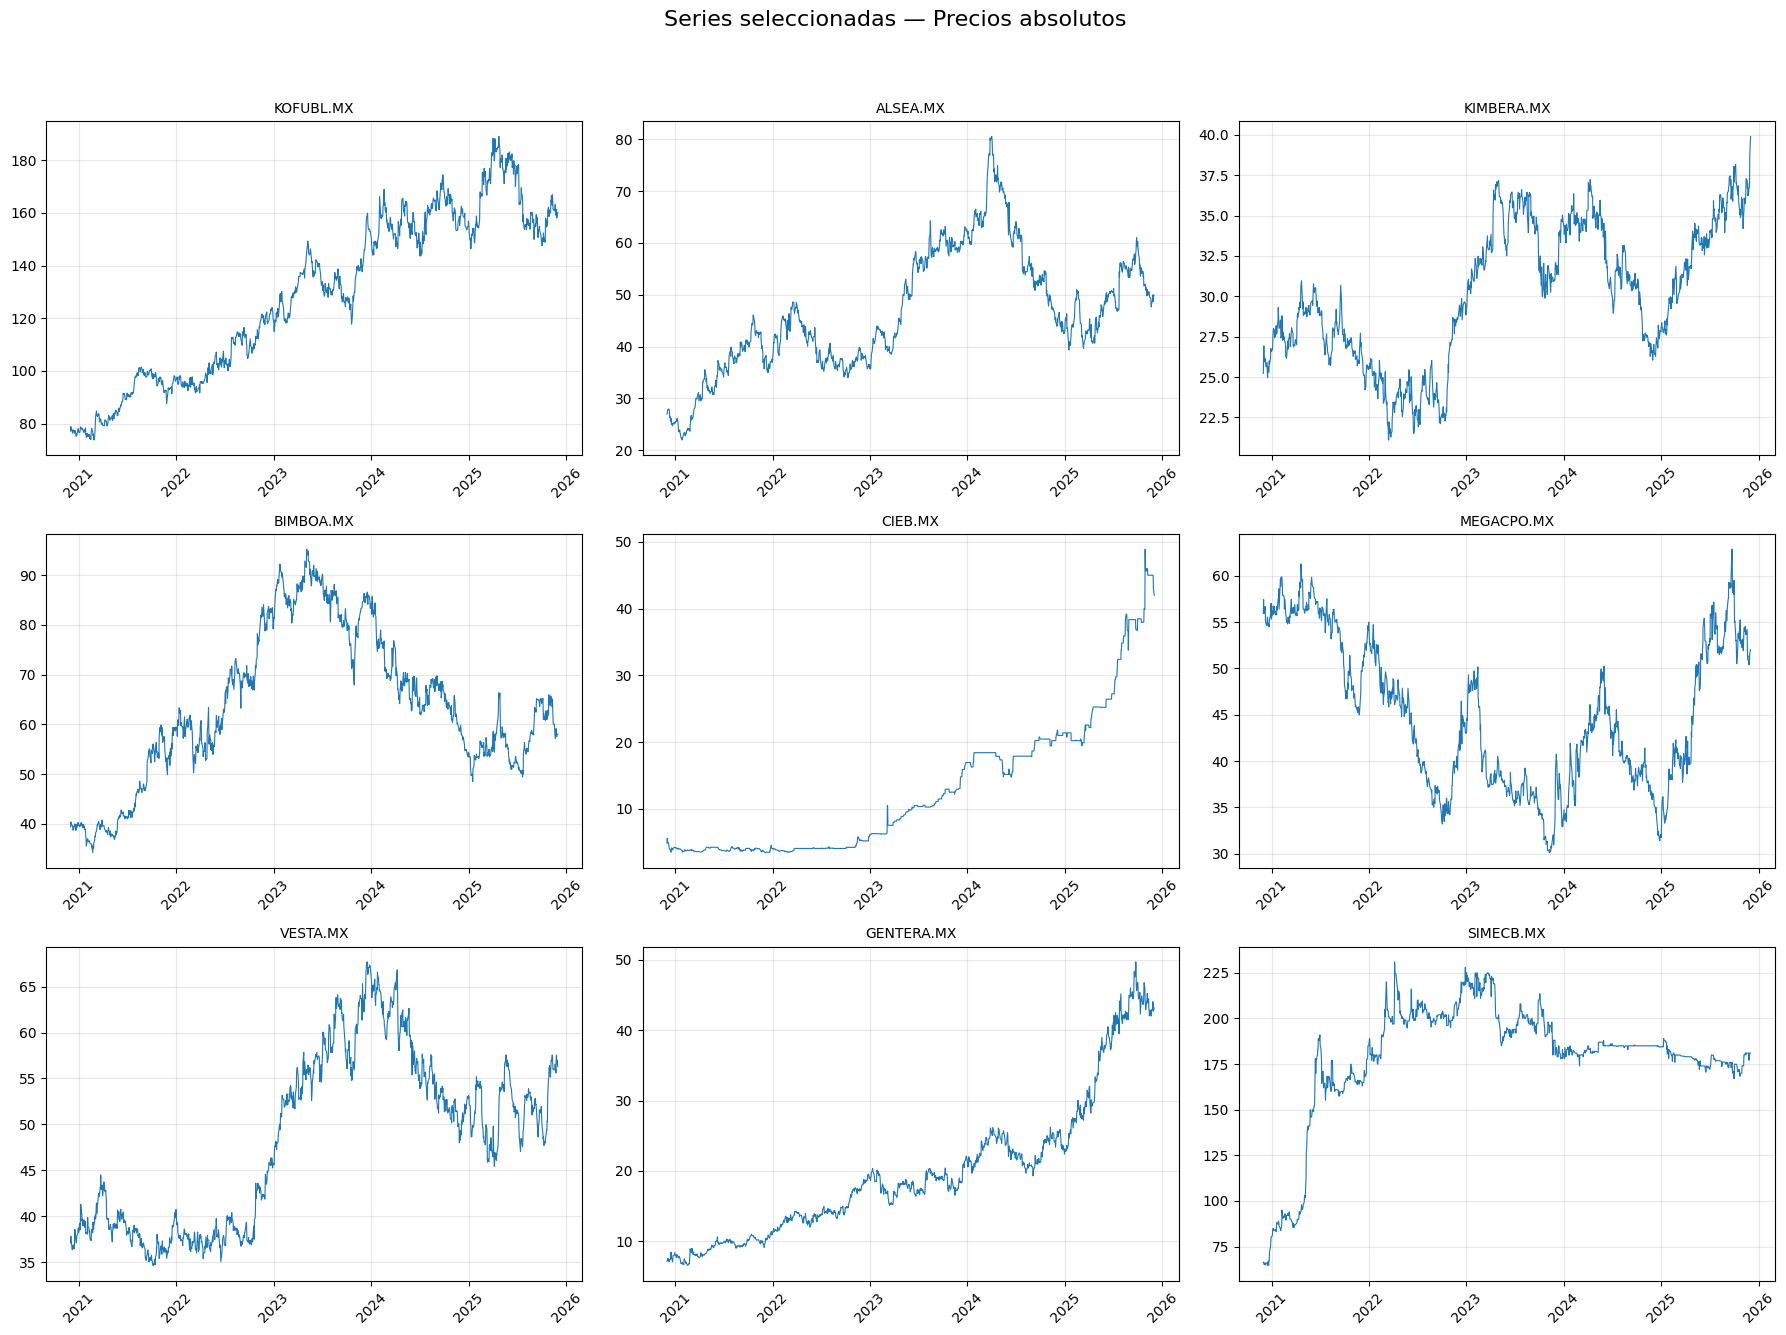

In [5]:
#
np.random.seed(42)
num_series_to_plot = min(9, len(precios_filtered_by_tickers.columns))
selected_tickers = np.random.choice(precios_filtered_by_tickers.columns, num_series_to_plot, replace=False)

fig, axs = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Series seleccionadas — Precios absolutos', fontsize=16)
for i, ticker in enumerate(selected_tickers):
    ax = axs.flatten()[i]
    ax.plot(precios_filtered_by_tickers[ticker], linewidth=0.8)
    ax.set_title(ticker, fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

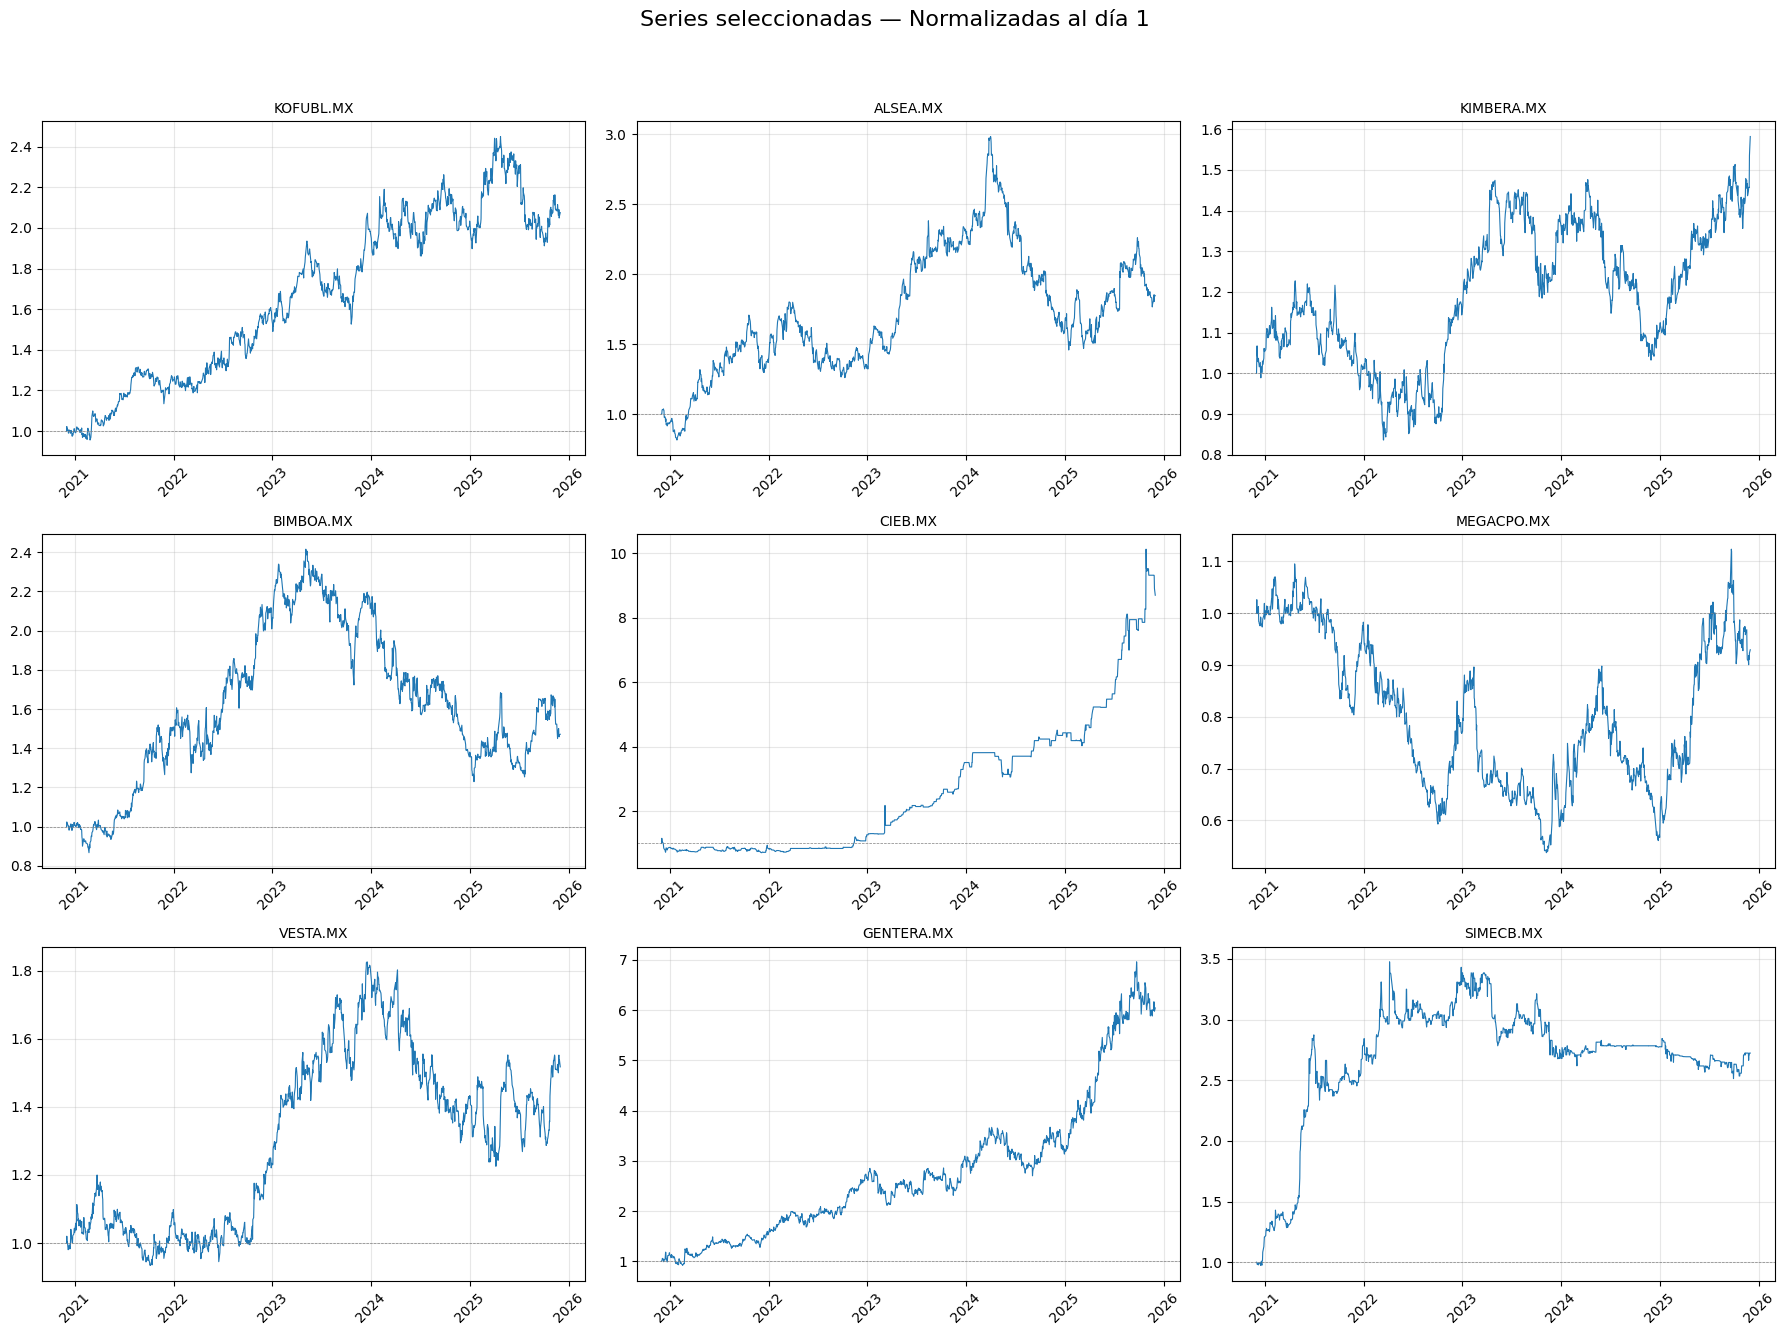

In [6]:
#
fig, axs = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Series seleccionadas — Normalizadas al día 1', fontsize=16)
for i, ticker in enumerate(selected_tickers):
    ax = axs.flatten()[i]
    series = precios_filtered_by_tickers[ticker]
    ax.plot(series / series.iloc[0], linewidth=0.8)
    ax.set_title(ticker, fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.5)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 3. ClusteringImportamos el módulo `time_series_clustering_class` que implementa los cuatro enfoques desde cero (sin depender de tslearn). También definimos una función utilitaria para construir las matrices de datos con distintas normalizaciones.

In [7]:
#
from time_series_clustering_class import (
    extract_feature_matrix, cluster_feature_kmeans,
    pairwise_dtw_matrix, cluster_dtw_hierarchical, cluster_dtw_spectral,
    cluster_model_ar,
    plot_feature_space_scatter, plot_medoids, plot_dendrogram,
    plot_affinity, distance_to_affinity
)

RANDOM_STATE = 0

In [8]:
#
def build_matrix_from_mapping(mapping, tickers, how="inner", normalize="first"):
    """
    Construye un DataFrame alineado y su representación numpy.

    Parámetros:
        normalize: "first" (divide por primer valor), "z" (z-score), None (sin normalizar)
    Retorna:
        df: DataFrame (index=fecha, columns=tickers)
        X:  array (n_series, T) — filas=series, columnas=tiempo
    """
    if hasattr(mapping, "columns"):
        df = mapping[tickers].copy()
    else:
        cols = [mapping[t].copy().rename(t) for t in tickers]
        df = pd.concat(cols, axis=1, join=how)

    df = df.sort_index().ffill().bfill()

    if normalize == "first":
        df = df / df.iloc[0]
    elif normalize == "z":
        df = (df - df.mean()) / (df.std(ddof=0).replace(0, np.nan))
        df = df.fillna(0)

    X = df.values.T  # (n_series, T)
    return df, X

In [9]:
#
tickers = precios_filtered_by_tickers.columns

# Dos normalizaciones: retorno acumulado (first) y z-score
df_first, X_first = build_matrix_from_mapping(precios_filtered_by_tickers, tickers, normalize="first")
df_z,     X_z     = build_matrix_from_mapping(precios_filtered_by_tickers, tickers, normalize="z")

print(f"X_first: {X_first.shape}  (series × tiempo)")
print(f"X_z:     {X_z.shape}  (series × tiempo)")

X_first: (55, 1260)  (series × tiempo)
X_z:     (55, 1260)  (series × tiempo)


In [10]:
# Versión mejorada de plot_series_by_cluster con colores por cluster y curva media
def plot_series_by_cluster(X, labels, n_per_cluster=5, savepath=None,
                           title=None, cmap="tab10", alpha=0.35, lw=1.2):
    """
    Dibuja hasta n_per_cluster series por clúster con un color fijo
    y superpone la media de cada clúster con una línea más gruesa.
    """
    t = np.arange(X.shape[1])
    clusters = np.unique(labels)
    cmap_obj = plt.get_cmap("tab20" if len(clusters) > 10 else cmap)
    colors = cmap_obj(np.linspace(0, 1, max(len(clusters), 2)))

    fig, ax = plt.subplots(figsize=(10, 6))
    for ci, c in enumerate(clusters):
        color = colors[ci]
        idx = np.where(labels == c)[0]
        sample = idx[:n_per_cluster]
        for i in sample:
            ax.plot(t, X[i], linewidth=lw, color=color, alpha=alpha)
        mean_curve = X[idx].mean(axis=0)
        ax.plot(t, mean_curve, linewidth=2.6, color=color, alpha=0.95,
                label=f"Cluster {c} (n={len(idx)})")

    ax.set_title(title or "Series por clúster")
    ax.set_xlabel("t"); ax.set_ylabel("nivel (normalizado)")
    ax.legend(loc="best", frameon=False)
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=150)
    plt.show()
    plt.close(fig)

## 3.0 Selección del número de clusters (k)Antes de elegir un k arbitrario, evaluamos la métrica **silhouette** para distintos valores de k usando el enfoque feature-based. Valores más altos de silhouette indican clusters más compactos y mejor separados.

Matriz de features: (55, 23)


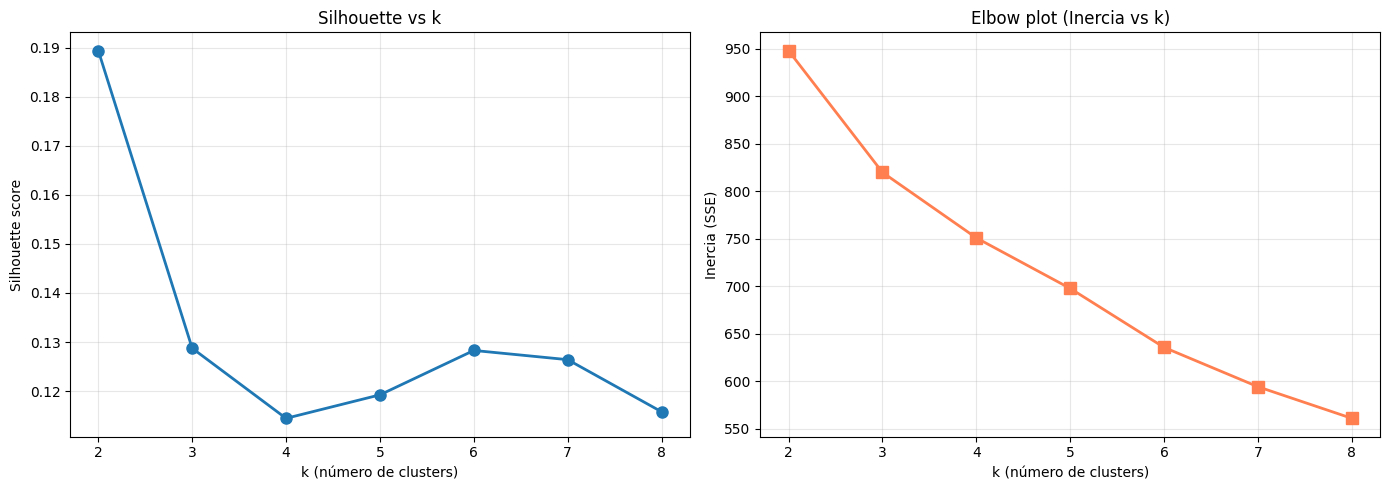


Mejor silhouette: 0.189 en k=2
Nota: elegimos k=3 para las siguientes secciones (ajustar según los resultados anteriores)


In [11]:
# Extraer features una sola vez (se reusan en la sección 3.1)
feats = extract_feature_matrix(X_z, p_ar=3, k_fft=5, n_segments_sax=12, sax_alpha=7)
print(f"Matriz de features: {feats.shape}")

# Evaluar silhouette para k = 2..8
scaler = StandardScaler()
Z_scaled = scaler.fit_transform(feats.values)

k_range = range(2, 9)
silhouettes = []
inertias = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labs = km.fit_predict(Z_scaled)
    silhouettes.append(silhouette_score(Z_scaled, labs))
    inertias.append(km.inertia_)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(k_range), silhouettes, 'o-', linewidth=2, markersize=8)
ax1.set_xlabel('k (número de clusters)')
ax1.set_ylabel('Silhouette score')
ax1.set_title('Silhouette vs k')
ax1.grid(True, alpha=0.3)

ax2.plot(list(k_range), inertias, 's-', linewidth=2, markersize=8, color='coral')
ax2.set_xlabel('k (número de clusters)')
ax2.set_ylabel('Inercia (SSE)')
ax2.set_title('Elbow plot (Inercia vs k)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_k = list(k_range)[np.argmax(silhouettes)]
print(f"\nMejor silhouette: {max(silhouettes):.3f} en k={best_k}")
print("Nota: elegimos k=3 para las siguientes secciones (ajustar según los resultados anteriores)")

In [12]:
N_CLUSTERS = 3  # ← ajustar según el análisis de la celda anterior

## 3.1 Clustering feature-based (K-Means)Este enfoque extrae un vector de características de cada serie:- **Estadísticas básicas:** media, desviación estándar, pendiente de tendencia lineal.- **Autocorrelaciones** (lags 1–4): capturan dependencia temporal.- **Potencias FFT** (top 5): capturan periodicidades dominantes.- **Coeficientes AR(3):** capturan la dinámica autorregresiva.- **Histograma SAX:** representación simbólica que captura la distribución de niveles.Luego se aplica K-Means en el espacio estandarizado de estas features.

In [13]:
#
res_feat, Z2, pca = cluster_feature_kmeans(feats, n_clusters=N_CLUSTERS, random_state=RANDOM_STATE)

print(f"Silhouette (feature-based K-Means): {res_feat.silhouette:.3f}")
print(f"Varianza explicada PCA (2 comp.): {pca.explained_variance_ratio_.sum():.1%}")

Silhouette (feature-based K-Means): 0.129
Varianza explicada PCA (2 comp.): 45.3%


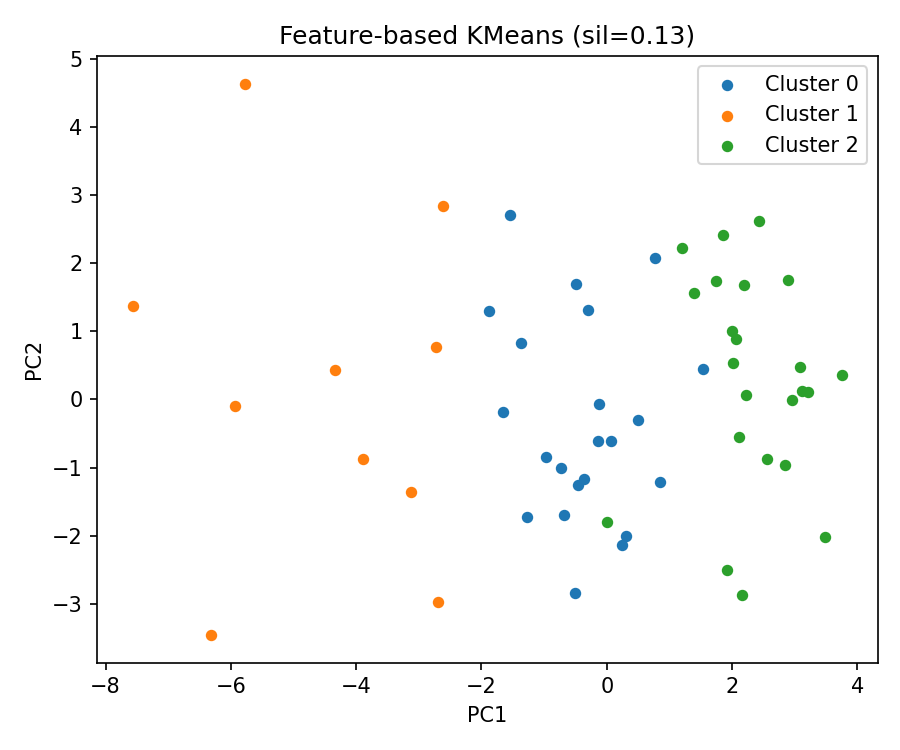

In [14]:
# Dispersión en PCA coloreada por cluster
plot_feature_space_scatter(
    Z2, res_feat.labels,
    title=f"Feature-based KMeans (sil={res_feat.silhouette:.2f})",
    savepath="feature_space_scatter.png"
)
display(Image("feature_space_scatter.png"))

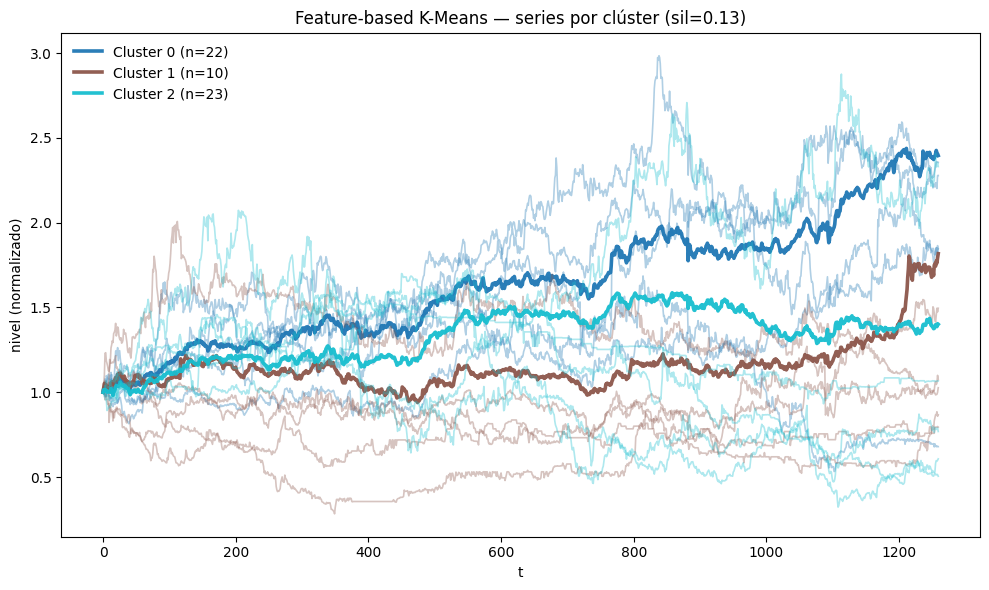

In [15]:
# Series normalizadas al día 1, coloreadas por cluster
plot_series_by_cluster(
    X_first, res_feat.labels, n_per_cluster=5,
    title=f"Feature-based K-Means — series por clúster (sil={res_feat.silhouette:.2f})"
)

In [16]:
# Guardar etiquetas
df_labels = pd.DataFrame({"ticker": tickers})
df_labels["cluster_feature"] = res_feat.labels
df_labels.to_csv("labels_feature_kmeans.csv", index=False)
df_labels.head()

,ticker,cluster_feature
0,AC.MX,0
1,ALFAA.MX,1
2,AGUA.MX,0
3,ASURB.MX,0
4,ARA.MX,1


## 3.2 Clustering basado en forma — DTW + Jerárquico**Dynamic Time Warping (DTW)** es una medida de distancia elástica que permite alinear temporalmente dos series antes de medir su diferencia. A diferencia de la distancia euclídea, DTW puede capturar similitudes entre series que están desfasadas en el tiempo.El costo computacional de la matriz DTW es O(n² × T²), donde n es el número de series y T su longitud. Usamos una **ventana de Sakoe-Chiba** para restringir el warping y reducir el costo.⚠️ **Nota:** dependiendo del número de series y su longitud, esta celda puede tardar varios minutos.

In [17]:
%%time
# Calcular la matriz de distancias DTW (puede tardar — reducir window si es necesario)
DTW_WINDOW = 30  # ventana de Sakoe-Chiba en muestras (None = sin restricción)

D_dtw = pairwise_dtw_matrix(X_z, window=DTW_WINDOW)

print(f"Matriz DTW: {D_dtw.shape}")
print(f"Distancia DTW mín (excl. diag): {D_dtw[D_dtw > 0].min():.2f}")
print(f"Distancia DTW máx: {D_dtw.max():.2f}")
print(f"Distancia DTW mediana: {np.median(D_dtw[D_dtw > 0]):.2f}")

Matriz DTW: (55, 55)
Distancia DTW mín (excl. diag): 4.39
Distancia DTW máx: 69.44
Distancia DTW mediana: 42.14
CPU times: user 2min 56s, sys: 138 ms, total: 2min 56s
Wall time: 2min 59s


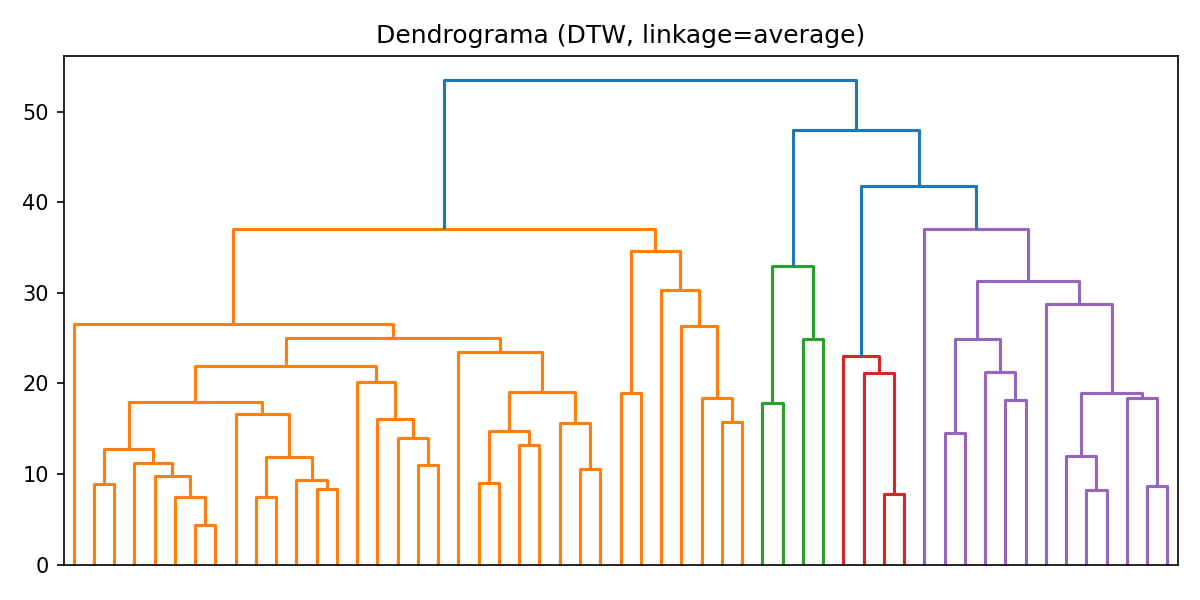

In [18]:
# Dendrograma
plot_dendrogram(D_dtw, title="Dendrograma (DTW, linkage=average)", savepath="dtw_dendrogram.png")
display(Image("dtw_dendrogram.png"))

In [19]:
# Clustering jerárquico con corte en N_CLUSTERS
res_hier = cluster_dtw_hierarchical(D_dtw, n_clusters=N_CLUSTERS, linkage='average')

print(f"Silhouette (DTW jerárquico): {res_hier.silhouette:.3f}")

# Distribución de clusters
unique, counts = np.unique(res_hier.labels, return_counts=True)
for c, n in zip(unique, counts):
    print(f"  Cluster {c}: {n} series")

Silhouette (DTW jerárquico): 0.352
  Cluster 0: 34 series
  Cluster 1: 4 series
  Cluster 2: 17 series


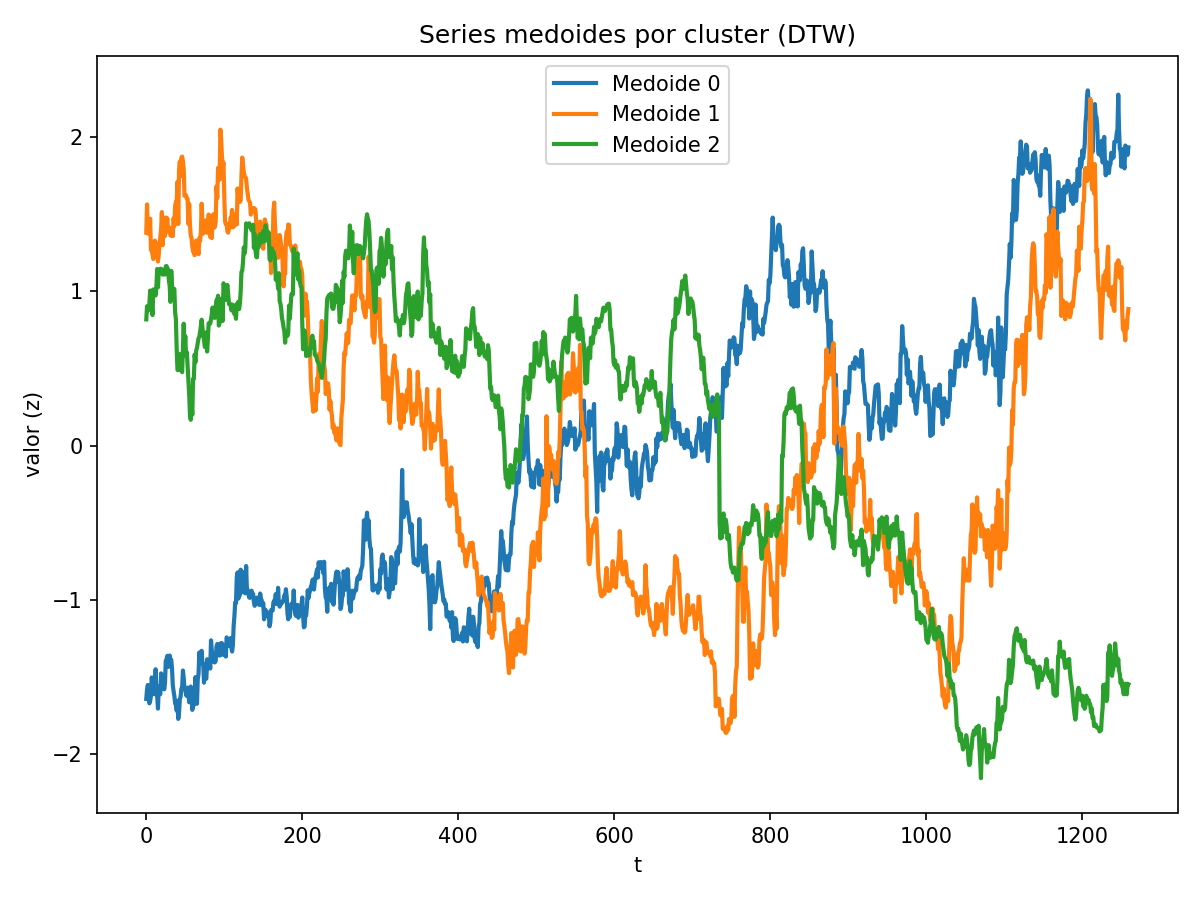

In [20]:
# Medoides y series por cluster
plot_medoids(X_z, D_dtw, res_hier.labels, savepath="medoids_hierarchical.png")
display(Image("medoids_hierarchical.png"))

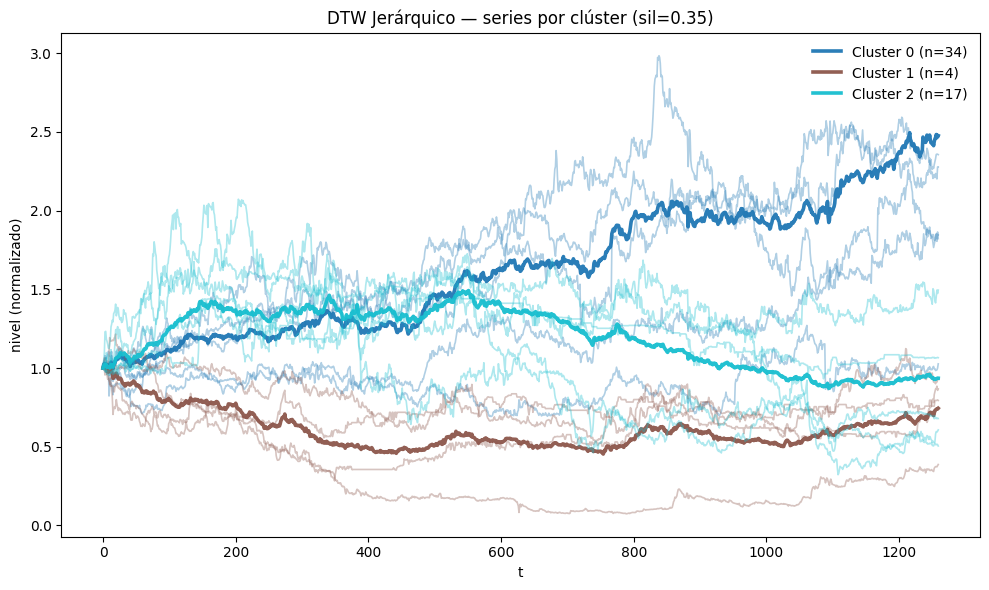

In [21]:
#
plot_series_by_cluster(
    X_first, res_hier.labels, n_per_cluster=5,
    title=f"DTW Jerárquico — series por clúster (sil={res_hier.silhouette:.2f})"
)

In [22]:
#
df_labels["cluster_dtw_hier"] = res_hier.labels

## 3.3 Clustering basado en forma — DTW + EspectralEl clustering espectral convierte la matriz de distancias DTW en una **matriz de afinidad** (usando un kernel RBF con σ = mediana de las distancias) y luego busca clusters en el espacio de los eigenvectors del Laplaciano del grafo. Este enfoque puede capturar estructuras no convexas que K-Means o el jerárquico pueden perder.

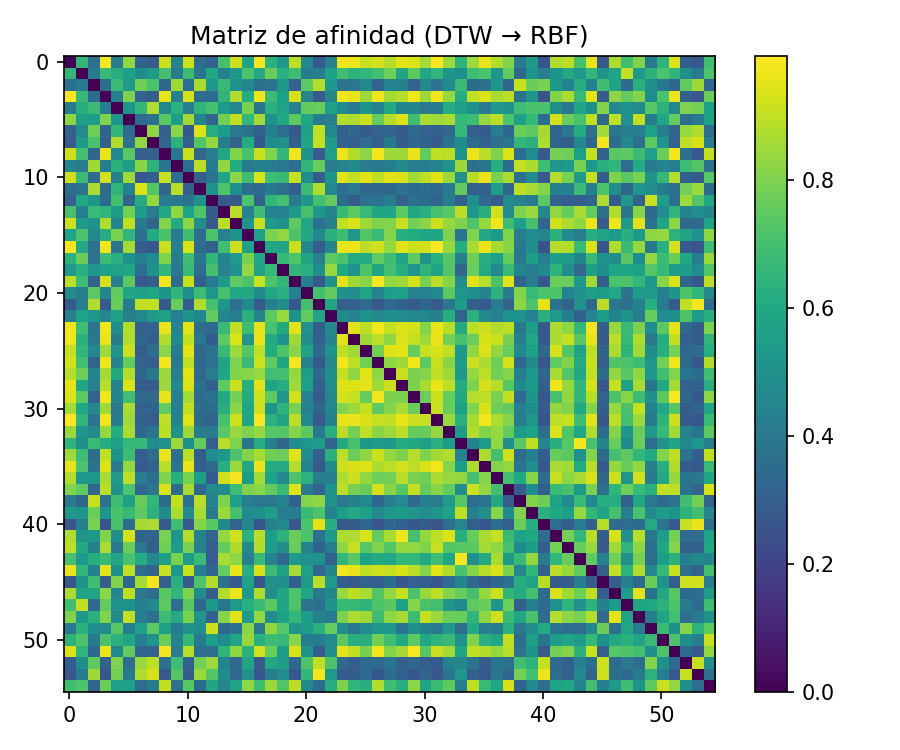

In [23]:
# Convertir distancias a afinidad y visualizar
A = distance_to_affinity(D_dtw)
plot_affinity(A, title="Matriz de afinidad (DTW → RBF)", savepath="affinity_matrix.png")
display(Image("affinity_matrix.png"))

In [24]:
#
res_spec = cluster_dtw_spectral(D_dtw, n_clusters=N_CLUSTERS, random_state=RANDOM_STATE)

print(f"Silhouette (DTW espectral): {res_spec.silhouette:.3f}")

unique, counts = np.unique(res_spec.labels, return_counts=True)
for c, n in zip(unique, counts):
    print(f"  Cluster {c}: {n} series")

Silhouette (DTW espectral): 0.322
  Cluster 0: 27 series
  Cluster 1: 14 series
  Cluster 2: 14 series


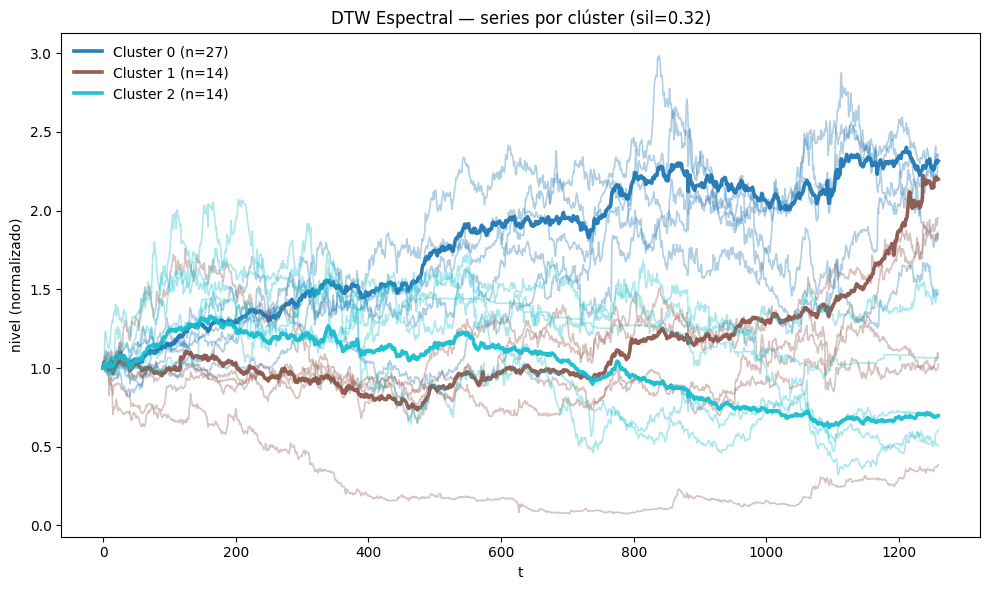

In [25]:
#
plot_series_by_cluster(
    X_first, res_spec.labels, n_per_cluster=5,
    title=f"DTW Espectral — series por clúster (sil={res_spec.silhouette:.2f})"
)

In [ ]:
df_labels["cluster_dtw_spectral"] = res_spec.labels

## 3.4 Clustering basado en modelo — AR(p)Este enfoque es más parsimonioso: en lugar de extraer muchas features, ajusta un modelo autorregresivo AR(p) a cada serie (por mínimos cuadrados) y usa los **p coeficientes + la desviación estándar residual** como representación. Luego aplica K-Means en ese espacio de parámetros.La intuición es que series generadas por procesos similares tendrán coeficientes AR parecidos.

In [26]:
# Los coeficientes AR ya están en la matriz de features
ar_cols = [c for c in feats.columns if c.startswith('ar')]
print(f"Columnas AR usadas: {ar_cols}")

res_ar = cluster_model_ar(feats[ar_cols].values, n_clusters=N_CLUSTERS, random_state=RANDOM_STATE)

print(f"Silhouette (model-based AR): {res_ar.silhouette:.3f}")

unique, counts = np.unique(res_ar.labels, return_counts=True)
for c, n in zip(unique, counts):
    print(f"  Cluster {c}: {n} series")

Columnas AR usadas: ['ar1', 'ar2', 'ar3', 'ar_sigma']
Silhouette (model-based AR): 0.296
  Cluster 0: 24 series
  Cluster 1: 16 series
  Cluster 2: 15 series


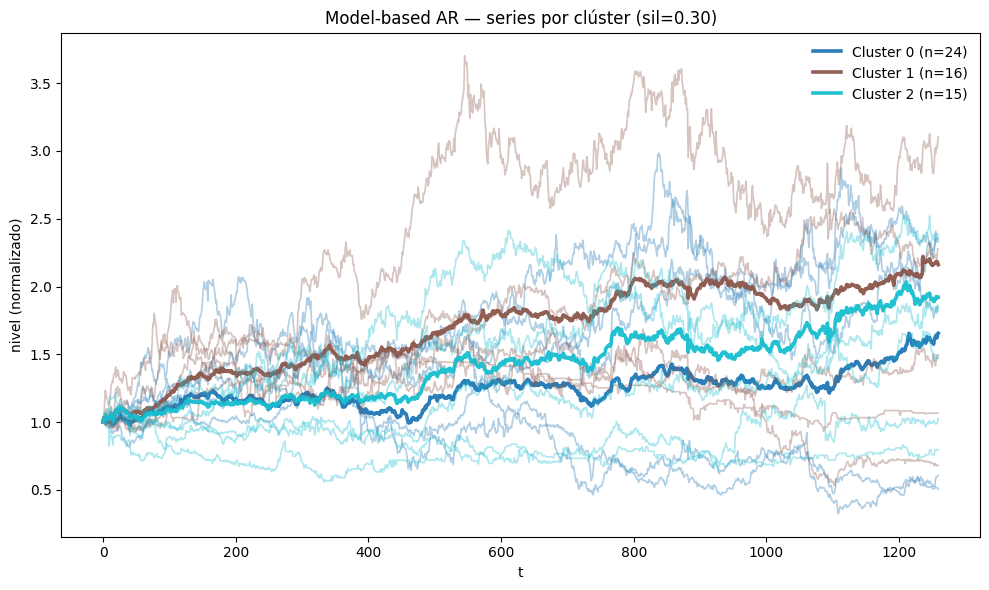

In [27]:
#
plot_series_by_cluster(
    X_first, res_ar.labels, n_per_cluster=5,
    title=f"Model-based AR — series por clúster (sil={res_ar.silhouette:.2f})"
)

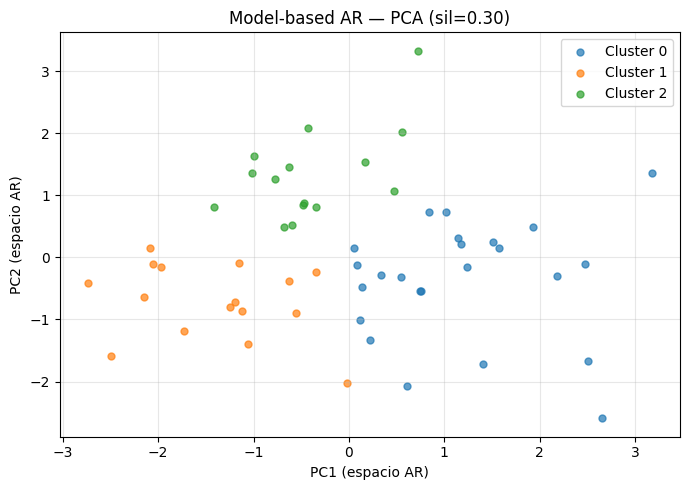

In [28]:
# Visualizar el espacio AR en 2D (PCA)
pca_ar = PCA(n_components=2, random_state=RANDOM_STATE)
Z_ar = pca_ar.fit_transform(StandardScaler().fit_transform(feats[ar_cols].values))

plt.figure(figsize=(7, 5))
for c in np.unique(res_ar.labels):
    mask = res_ar.labels == c
    plt.scatter(Z_ar[mask, 0], Z_ar[mask, 1], label=f"Cluster {c}", s=25, alpha=0.7)
plt.xlabel("PC1 (espacio AR)")
plt.ylabel("PC2 (espacio AR)")
plt.title(f"Model-based AR — PCA (sil={res_ar.silhouette:.2f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
df_labels["cluster_ar_model"] = res_ar.labels

# 4. Comparación de enfoquesComparamos los cuatro métodos lado a lado usando la métrica silhouette y analizamos la concordancia entre las asignaciones de clusters.

In [29]:
# Resumen de métricas
results = {
    "Feature-based K-Means": res_feat.silhouette,
    "DTW + Jerárquico": res_hier.silhouette,
    "DTW + Espectral": res_spec.silhouette,
    "Model-based AR": res_ar.silhouette,
}

print("=" * 50)
print(f"{'Método':<25} {'Silhouette':>10}")
print("=" * 50)
for method, sil in results.items():
    bar = '█' * int(sil * 40) if sil > 0 else ''
    print(f"{method:<25} {sil:>10.3f}  {bar}")
print("=" * 50)

Método                    Silhouette
Feature-based K-Means          0.129  █████
DTW + Jerárquico               0.352  ██████████████
DTW + Espectral                0.322  ████████████
Model-based AR                 0.296  ███████████


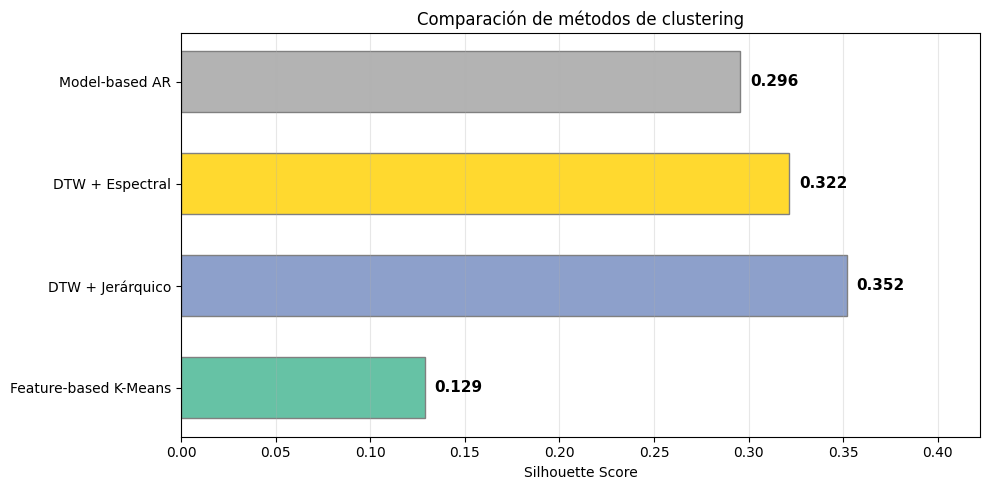

In [30]:
# Comparación visual de silhouettes
fig, ax = plt.subplots(figsize=(10, 5))
methods = list(results.keys())
sils = list(results.values())
colors = plt.cm.Set2(np.linspace(0, 1, len(methods)))

bars = ax.barh(methods, sils, color=colors, edgecolor='gray', height=0.6)
ax.set_xlabel('Silhouette Score')
ax.set_title('Comparación de métodos de clustering')
ax.set_xlim(0, max(sils) * 1.2 if max(sils) > 0 else 1)
ax.grid(True, axis='x', alpha=0.3)

for bar, val in zip(bars, sils):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [32]:
# Guardar todas las etiquetas
df_labels.to_csv("labels_all_methods.csv", index=False)
print(f"Etiquetas guardadas para {len(df_labels)} tickers con {len(df_labels.columns)-1} métodos")
df_labels.head(10)

Etiquetas guardadas para 55 tickers con 2 métodos


,ticker,cluster_feature,cluster_dtw_hier
0,AC.MX,0,0
1,ALFAA.MX,1,0
2,AGUA.MX,0,2
3,ASURB.MX,0,0
4,ARA.MX,1,2
5,ALSEA.MX,0,0
6,ALPEKA.MX,2,2
7,VOLARA.MX,2,2
8,PINFRA.MX,0,0
9,POCHTECB.MX,2,2


# 5. Conclusiones**Resumen de lo aprendido:
**- El clustering de series de tiempo requiere elegir cuidadosamente tanto la **representación** de las series como la **métrica de distancia** y el **algoritmo de agrupamiento**.- El enfoque **feature-based** es rápido y escalable, pero puede perder información sobre la forma temporal exacta de las series.- **DTW** captura mejor las similitudes de forma (incluso con desfases temporales), pero su costo cuadrático lo hace impráctico para datasets muy grandes.- El enfoque **model-based (AR)** es parsimonioso y eficiente, ideal cuando la dinámica autorregresiva es el factor diferenciador relevante.- El **clustering espectral** sobre la afinidad DTW puede descubrir estructuras que los métodos más simples no detectan.- La **selección de k** es un paso fundamental — la métrica silhouette y el elbow plot dan señales complementarias.**Posibles extensiones:**- Probar con otras distancias elásticas (soft-DTW, distancia de Fréchet).- Usar representaciones aprendidas (autoencoders, embeddings).- Explorar clustering con número variable de clusters (DBSCAN, HDBSCAN).- Analizar la estabilidad de los clusters con bootstrap o validación cruzada.